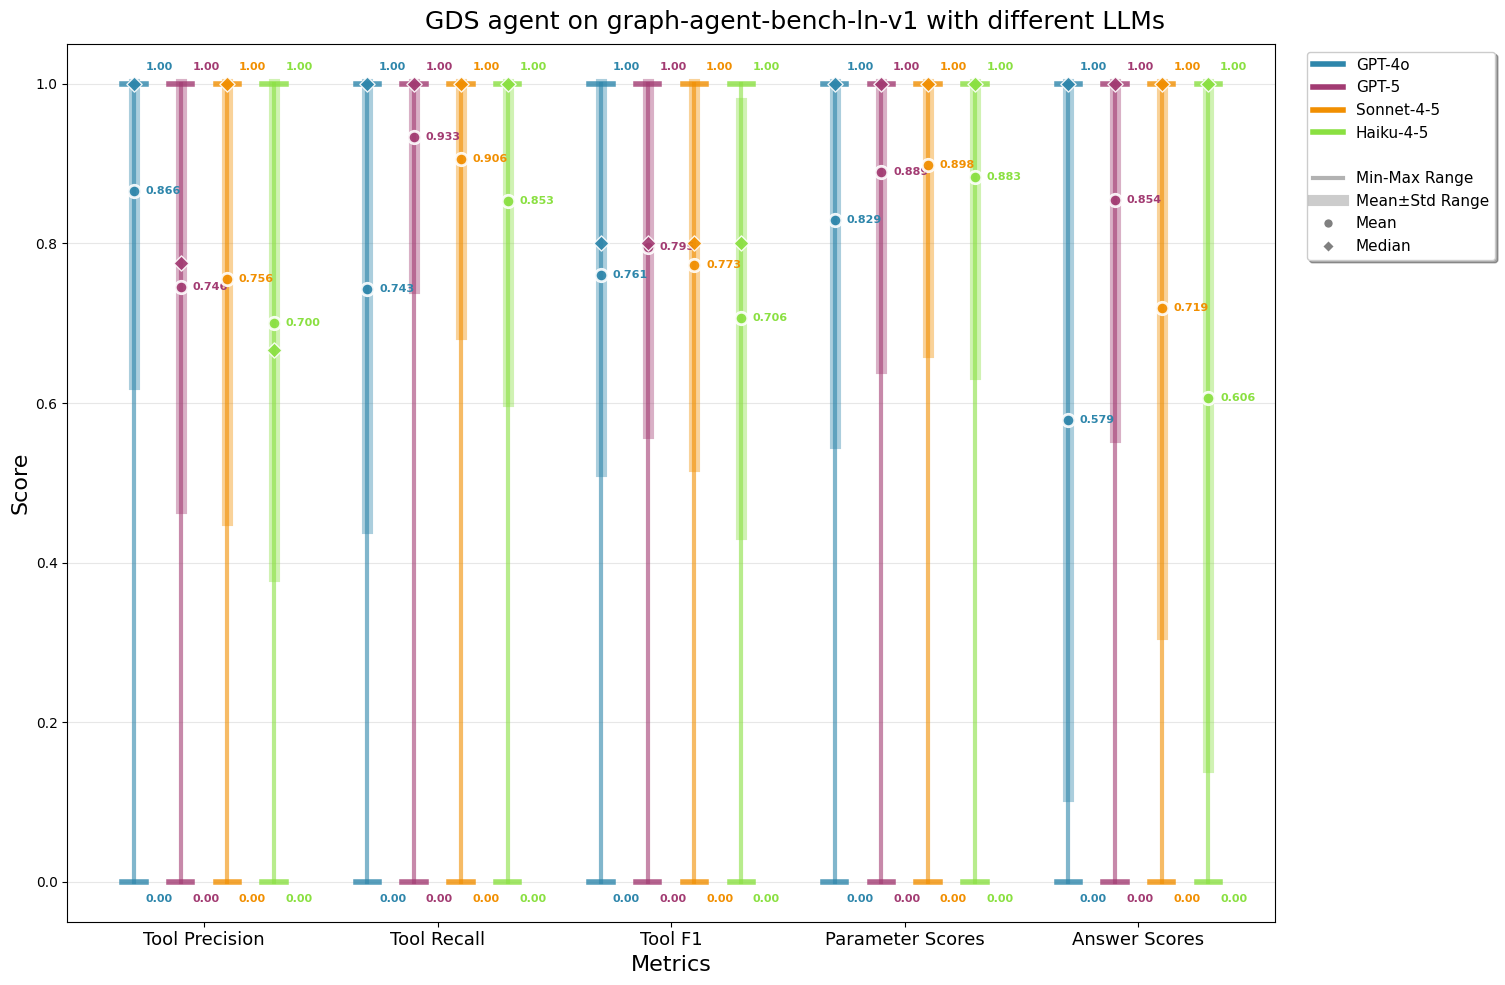

In [ ]:
# Plot for LN

import matplotlib.pyplot as plt
import numpy as np

models = ['GPT-4o', 'GPT-5', 'Sonnet-4-5', 'Haiku-4-5'] 
metrics = ['Tool Precision', 'Tool Recall', 'Tool F1', 'Parameter Scores', 'Answer Scores']

# Copy results from analysis output
gpt_4o_data = {
    'mean': [0.866, 0.743, 0.761, 0.829, 0.579],
    'std': [0.242, 0.300, 0.246, 0.279, 0.472],
    'median': [1.000, 1.000, 0.800, 1.000, 1.000],
    'min': [0.000, 0.000, 0.000, 0.000, 0.000],
    'max': [1.000, 1.000, 1.000, 1.000, 1.000]
}
gpt_5_data = {
    'mean': [0.746, 0.933, 0.795, 0.889, 0.854],
    'std': [0.278, 0.189, 0.233, 0.245, 0.296],
    'median': [0.775, 1.000, 0.800, 1.000, 1.000],
    'min': [0.000, 0.000, 0.000, 0.000, 0.000],
    'max': [1.000, 1.000, 1.000, 1.000, 1.000]
}
haiku_4_5 = {
    'mean': [0.700, 0.853, 0.706, 0.883, 0.606],
    'std': [0.317, 0.251, 0.270, 0.247, 0.462],
    'median': [0.667, 1.0, 0.8, 1.0, 1.0],
    'min': [0.0, 0.0, 0.0, 0.0, 0.0],
    'max': [1.000, 1.000, 1.000, 1.000, 1.000]
}
soonet_4_5 = {
    'mean': [0.756, 0.906, 0.773, 0.898, 0.719],
    'std': [0.303, 0.219, 0.252, 0.234, 0.409],
    'median': [1.0, 1.0, 0.8, 1.0, 1.0],
    'min': [0.0, 0.0, 0.0, 0.0, 0.0],
    'max': [1.000, 1.000, 1.000, 1.000, 1.000]
}


model_data = {
    'GPT-4o': gpt_4o_data,
    'GPT-5': gpt_5_data,
    'Sonnet-4-5': soonet_4_5,
    'Haiku-4-5': haiku_4_5
}


colors = ['#2E86AB', '#A23B72', '#F18F01', '#8AE041']
fig, ax = plt.subplots(figsize=(16, 10))
x_positions = np.arange(len(metrics))
width = 0.2 

for i, (model, color) in enumerate(zip(models, colors)):
    means = model_data[model]['mean']
    stds = model_data[model]['std']
    mins = model_data[model]['min']
    maxs = model_data[model]['max']
    medians = model_data[model]['median']
    
    x_offset = x_positions + (i - len(models)/2 + 0.5) * width
    
    for j, x in enumerate(x_offset):
        mean_val = means[j]
        std_val = stds[j]
        min_val = mins[j]
        max_val = maxs[j]
        median_val = medians[j]
        
        ax.plot([x, x], [min_val, max_val], color=color, linewidth=3, alpha=0.6, label=model if j == 0 else "")
        ax.plot([x-width/4, x+width/4], [min_val, min_val], color=color, linewidth=4, alpha=0.8)
        
        ax.plot([x-width/4, x+width/4], [max_val, max_val], color=color, linewidth=4, alpha=0.8)
        
        ax.scatter(x, mean_val, color=color, s=80, alpha=0.9, zorder=5, edgecolors='white', linewidth=2)
        
        std_lower = max(min_val, mean_val - std_val)
        std_upper = min(max_val, mean_val + std_val)
        ax.plot([x, x], [std_lower, std_upper], color=color, linewidth=8, alpha=0.4)
        
        ax.scatter(x, median_val, color=color, s=60, alpha=0.9, zorder=5, marker='D', edgecolors='white', linewidth=1)
        
        label_offset = 0.015
        horizontal_offset = 0.05
        ax.text(x + horizontal_offset, max_val + label_offset, f'{max_val:.2f}', ha='left', va='bottom', 
                fontsize=8, color=color, fontweight='bold')
        ax.text(x + horizontal_offset, mean_val, f'{mean_val:.3f}', ha='left', va='center', 
                fontsize=8, color=color, fontweight='bold')
        ax.text(x + horizontal_offset, min_val - label_offset, f'{min_val:.2f}', ha='left', va='top', 
                fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=16)
ax.set_ylabel('Score', fontsize=16)

ax.set_xticks(x_positions)
ax.set_xticklabels(metrics, fontsize=13)

ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(-0.05, 1.05)

from matplotlib.lines import Line2D
legend_elements = []

for model, color in zip(models, colors):
    legend_elements.append(Line2D([0], [0], color=color, lw=4, label=model))

legend_elements.append(Line2D([0], [0], color='white', lw=0, label=''))  # Empty separator
legend_elements.append(Line2D([0], [0], color='gray', lw=3, alpha=0.6, label='Min-Max Range'))
legend_elements.append(Line2D([0], [0], color='gray', lw=8, alpha=0.4, label='Mean±Std Range'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                              markersize=8, label='Mean', markeredgecolor='white', markeredgewidth=2))
legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', 
                              markersize=6, label='Median', markeredgecolor='white', markeredgewidth=1))

legend = ax.legend(handles=legend_elements, 
                   bbox_to_anchor=(1.02, 1), 
                   loc='upper left',
                   fontsize=11, 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   title_fontsize=12)

fig.suptitle('GDS agent on graph-agent-bench-ln-v1 with different LLMs', 
             fontsize=18, y=0.98)

plt.tight_layout()
plt.subplots_adjust(right=0.80)

plt.savefig('llm_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('llm_model_comparison.pdf', bbox_inches='tight', facecolor='white')

plt.show()

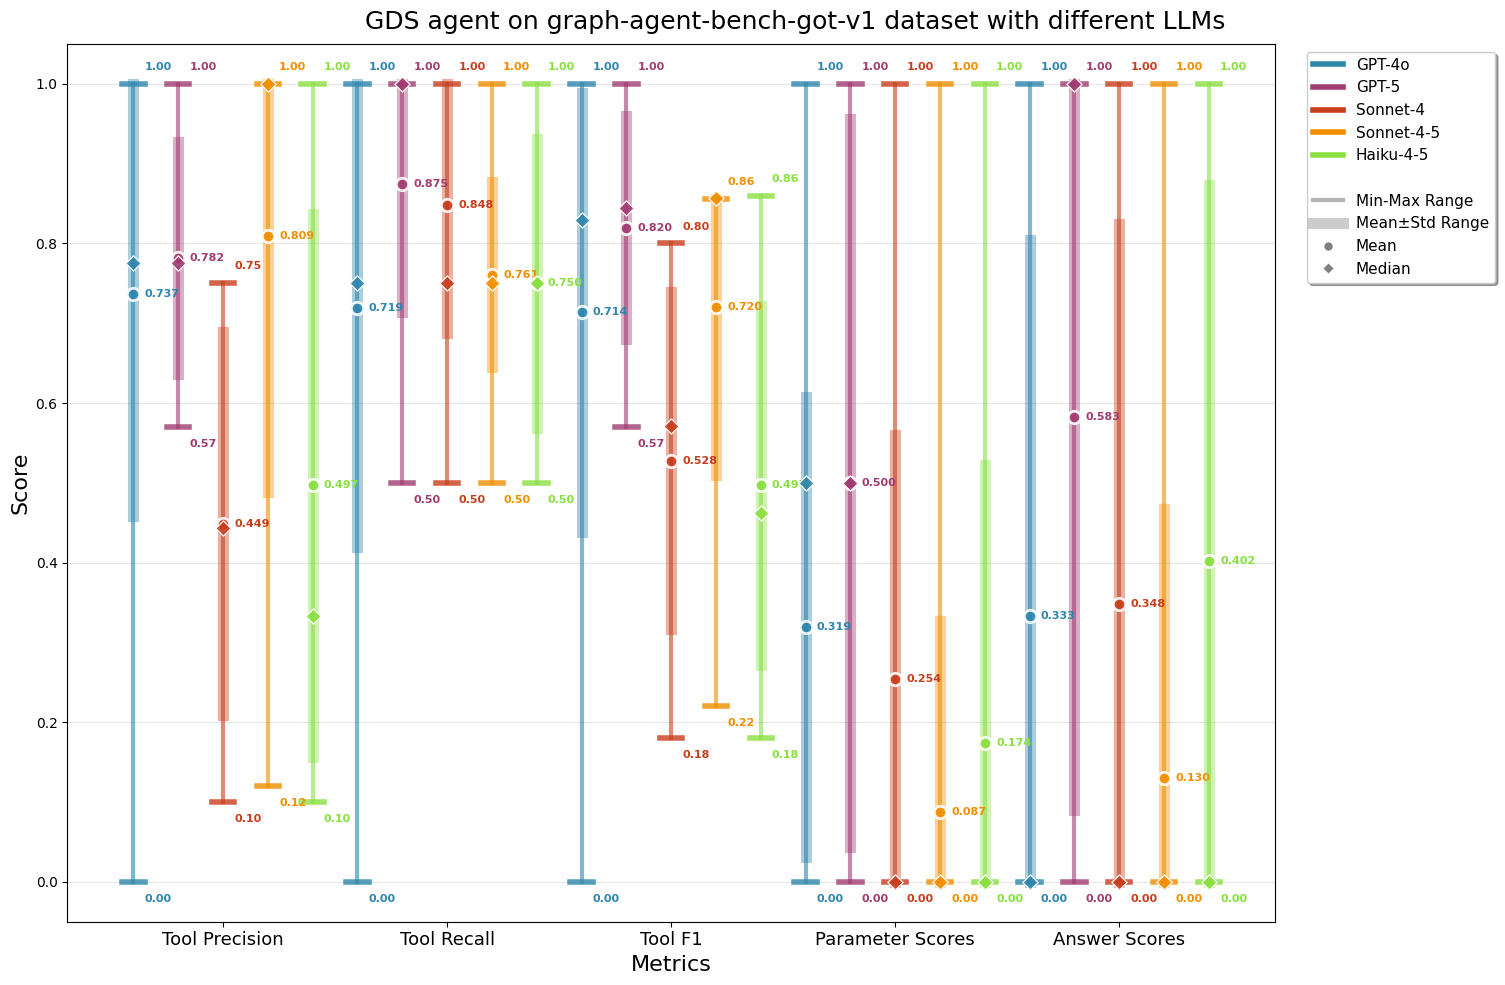

In [ ]:
# Plot for GoT dataset

models = ['GPT-4o', 'GPT-5', 'Sonnet-4', 'Sonnet-4-5', 'Haiku-4-5']
metrics = ['Tool Precision', 'Tool Recall', 'Tool F1', 'Parameter Scores', 'Answer Scores']

# Copy results from analysis output
gpt_4o_data = {
    'mean': [0.737, 0.719, 0.714, 0.319, 0.333],
    'std': [0.279, 0.300, 0.275, 0.288, 0.471],
    'median': [0.775, 0.750, 0.829, 0.500, 0.000],
    'min': [0.0, 0.0, 0.0, 0.0, 0.0],
    'max': [1.0, 1.0, 1.0, 1.0, 1.0]
}
gpt_5_data = {
    'mean': [0.782, 0.875, 0.820, 0.500, 0.583],
    'std': [0.145, 0.161, 0.140, 0.456, 0.493],
    'median': [0.775, 1.000, 0.844, 0.500, 1.000],
    'min': [0.57, 0.5, 0.57, 0.0, 0.0],
    'max': [1.0, 1.0, 1.0, 1.0, 1.0]
}
sonnet_4_data = {
    'mean': [0.449, 0.848, 0.528, 0.254, 0.348],
    'std': [0.240, 0.160, 0.211, 0.306, 0.476],
    'median': [0.444, 0.750, 0.571, 0.000, 0.000],
    'min': [0.10, 0.50, 0.18, 0.0, 0.0],
    'max': [0.75, 1.0, 0.8, 1.0, 1.0]
}
sonnet_4_5_data = {
    'mean': [0.809, 0.761, 0.720, 0.087, 0.130],
    'std': [0.320, 0.116, 0.210, 0.240, 0.337],
    'median': [1.000, 0.750, 0.857, 0.000, 0.000],
    'min': [0.12, 0.5, 0.22, 0.0, 0.0],
    'max': [1.0, 1.0, 0.856, 1.0, 1.0]
}
haiku_4_5 = {
    'mean': [0.497, 0.750, 0.497, 0.174, 0.402],
    'std': [0.340, 0.181, 0.225, 0.349, 0.471],
    'median': [0.333, 0.750, 0.462, 0.000, 0.000],
    'min': [0.10, 0.50, 0.18, 0.00, 0.00],
    'max': [1.0, 1.0, 0.86, 1.0, 1.0]
}


model_data = {
    'GPT-4o': gpt_4o_data,
    'GPT-5': gpt_5_data,
    'Sonnet-4': sonnet_4_data,
    'Sonnet-4-5': sonnet_4_5_data,
    'Haiku-4-5': haiku_4_5
}


colors = ['#2E86AB', '#A23B72', '#C73E1D', '#F18F01', '#8AE041']
fig, ax = plt.subplots(figsize=(16, 10))
x_positions = np.arange(len(metrics))
width = 0.2

for i, (model, color) in enumerate(zip(models, colors)):
    means = model_data[model]['mean']
    stds = model_data[model]['std']
    mins = model_data[model]['min']
    maxs = model_data[model]['max']
    medians = model_data[model]['median']
    
    x_offset = x_positions + (i - len(models)/2 + 0.5) * width
    for j, x in enumerate(x_offset):
        mean_val = means[j]
        std_val = stds[j]
        min_val = mins[j]
        max_val = maxs[j]
        median_val = medians[j]
        
        ax.plot([x, x], [min_val, max_val], color=color, linewidth=3, alpha=0.6, label=model if j == 0 else "")
        ax.plot([x-width/4, x+width/4], [min_val, min_val], color=color, linewidth=4, alpha=0.8)
        
        ax.plot([x-width/4, x+width/4], [max_val, max_val], color=color, linewidth=4, alpha=0.8)
        
        ax.scatter(x, mean_val, color=color, s=80, alpha=0.9, zorder=5, edgecolors='white', linewidth=2)
        
        std_lower = max(min_val, mean_val - std_val)
        std_upper = min(max_val, mean_val + std_val)
        ax.plot([x, x], [std_lower, std_upper], color=color, linewidth=8, alpha=0.4)
        
        ax.scatter(x, median_val, color=color, s=60, alpha=0.9, zorder=5, marker='D', edgecolors='white', linewidth=1)
        
        label_offset = 0.015
        horizontal_offset = 0.05  # Closer to the bars
        ax.text(x + horizontal_offset, max_val + label_offset, f'{max_val:.2f}', ha='left', va='bottom', 
                fontsize=8, color=color, fontweight='bold')
        ax.text(x + horizontal_offset, mean_val, f'{mean_val:.3f}', ha='left', va='center', 
                fontsize=8, color=color, fontweight='bold')
        ax.text(x + horizontal_offset, min_val - label_offset, f'{min_val:.2f}', ha='left', va='top', 
                fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=16)
ax.set_ylabel('Score', fontsize=16)

ax.set_xticks(x_positions)
ax.set_xticklabels(metrics, fontsize=13)

ax.grid(True, alpha=0.3, axis='y')

ax.set_ylim(-0.05, 1.05)

from matplotlib.lines import Line2D
legend_elements = []

for model, color in zip(models, colors):
    legend_elements.append(Line2D([0], [0], color=color, lw=4, label=model))

legend_elements.append(Line2D([0], [0], color='white', lw=0, label=''))  # Empty separator

legend_elements.append(Line2D([0], [0], color='gray', lw=3, alpha=0.6, label='Min-Max Range'))
legend_elements.append(Line2D([0], [0], color='gray', lw=8, alpha=0.4, label='Mean±Std Range'))
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                              markersize=8, label='Mean', markeredgecolor='white', markeredgewidth=2))
legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', 
                              markersize=6, label='Median', markeredgecolor='white', markeredgewidth=1))

legend = ax.legend(handles=legend_elements, 
                   bbox_to_anchor=(1.02, 1), 
                   loc='upper left',
                   fontsize=11, 
                   frameon=True, 
                   fancybox=True, 
                   shadow=True,
                   title_fontsize=12)

fig.suptitle('GDS agent on graph-agent-bench-got-v1 dataset with different LLMs', 
             fontsize=18, y=0.98)

plt.tight_layout()
plt.subplots_adjust(right=0.80)

plt.savefig('llm_model_comparison_got.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('llm_model_comparison_got.pdf', bbox_inches='tight', facecolor='white')

plt.show()